# Setup

In [100]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    import wandb
except ImportError:
    wandb = None
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import print_mol_types
from src.data.graph_building import build_graph_features
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import mask_data, preprocess
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.training.loops import train
from src.visualization.training_plots import plot_toxicity_distribution, plot_training
from src.data.splitting import (
    build_weighted_random_sampler,
    butina_split,
    compute_attribute_distribution,
    generate_scaffold,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete
Data file: /home/vollmers/gnn-thesis/Data/toxicity_all.csv


# Load And Filter Data


In [101]:
selected_columns = [
    'SK_unique_id',
    'species_common_name',
    'species_latin_name',
    'CAS',
    'chemical_name',
    'conc_unit',
    'conc',
    'duration',
    'duration_unit',
    'effect',
    'endpoint',
    'SMILES',
    'organism_lifestage_categorized',
    'administration_route_categorized',
    'NCBI_sci_name',
    'NCBI_last_known_rank',
    'NCBI_rank_superkingdom',
    'NCBI_rank_kingdom',
    'NCBI_rank_phylum',
    'NCBI_rank_subphylum',
    'NCBI_rank_class',
    'NCBI_rank_order',
    'NCBI_rank_family',
    'NCBI_rank_genus',
    'NCBI_rank_species',
    'species_group_corrected'
]

df_all = load_data(DATA_PATH, selected_columns)

df_all = df_all.rename(columns={
    'species_group_corrected': 'species_group',
    'organism_lifestage_categorized': 'organism_lifestage',
    'administration_route_categorized': 'administration_route'
})

# Rename columns starting with NCBI_ to be more concise
df_all = df_all.rename(columns={
    'NCBI_rank_superkingdom': 'superkingdom',
    'NCBI_rank_kingdom': 'kingdom',
    'NCBI_rank_phylum': 'phylum',
    'NCBI_rank_subphylum': 'subphylum',
    'NCBI_rank_class': 'class',
    'NCBI_rank_order': 'order',
    'NCBI_rank_family': 'family',
    'NCBI_rank_genus': 'genus',
    'NCBI_rank_species': 'species',
    'NCBI_sci_name': 'species_sci_name',
    'NCBI_last_known_rank': 'taxid'
})

print(df_all['duration'].value_counts())

# Fill missing organimsm_lifestage -> adult, administration_route -> fill, duration_unit -> h
df_all['organism_lifestage'] = df_all['organism_lifestage'].fillna('adult')
df_all['administration_route'] = df_all['administration_route'].fillna('fill')
df_all['duration_unit'] = df_all['duration_unit'].fillna('h')

# Filters
filters = {
    # "conc_unit": ["mg/L"],
    "duration_unit": ["h"],
    # "endpoint": ["EC50"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}
require_duration = False
require_taxonomy = True

taxonomy_cols = (
    "class",
    "family",
    "genus",
    "species",
)

# Create mask
mask = mask_data(
    df_all,
    filters=filters,
    require_duration=require_duration,
    require_taxonomy=require_taxonomy,
    taxonomy_columns=taxonomy_cols,
)

# Apply mask and filter
df_filtered = df_all.loc[mask].copy()

# Convert taxonomy columns to numeric, coercing errors to NaN and then to nullable Int64
for col in taxonomy_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors="coerce").astype("Int64")

print()
print("Loaded and filtered training data")
print(f"Rows in full data: {len(df_all):,}")
print(f"Rows after filter: {len(df_filtered):,}")
print()
print("Filtered preview")
print(df_filtered.head())


duration
96.00       64216
48.00       55824
24.00       45443
72.00       30372
168.00      19659
            ...  
219.36          1
510.24          1
301.68          1
51840.00        1
59040.00        1
Name: count, Length: 2309, dtype: int64
Filters
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxonomy: True
True: 0.916

Loaded and filtered training data
Rows in full data: 561,100
Rows after filter: 495,422

Filtered preview
  SK_unique_id species_common_name species_latin_name          CAS  \
0       RTECS7               mouse       Mus musculus  108073-64-9   
1      RTECS41               mouse       Mus musculus   78111-17-8   
2     RTECS137               mouse       Mus musculus    4657-93-6   
3     RTECS140               mouse       Mus musculus  102585-20-6   
4     RTECS141                 rat  Rattus norvegicus      83-32-9   

                                                                 

# Preprocess Molecules And Targets


In [ ]:
# Cut dataset for faster experiments
MAX_ROWS = 80000  # set to an integer like 15000 for faster experiments
# MAX_ROWS = None
random_state = 11

# Optionally limit the number of rows for faster experiments
if MAX_ROWS is not None and len(df_filtered) > MAX_ROWS:
    df_filtered = df_filtered.sample(n=MAX_ROWS, random_state=random_state).reset_index(drop=True)
else:
    df_filtered = df_filtered.reset_index(drop=True)


# Preprocess data
SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0
LOG_TRANSFORM_DURATION = True

df_processed = preprocess(
    df_filtered.copy(),
    split_salts=True,
    remove_lone=False,
    remove_metals=False,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

print(f"Rows before preprocessing: {len(df_filtered):,}")
print(f"Rows after preprocessing:  {len(df_processed):,}")
print(f"Rows removed: {len(df_filtered) - len(df_processed):,}")
print()
print("Preprocessed preview")
print(df_processed[["SMILES", "duration_raw", "duration", "conc", "log10c", "species_group"]].head())
print()
print_mol_types(df_processed)


[12:38:57] WARNING: not removing hydrogen atom without neighbors
[12:38:57] WARNING: not removing hydrogen atom without neighbors
[12:38:57] WARNING: not removing hydrogen atom without neighbors
[12:38:57] WARNING: not removing hydrogen atom without neighbors
[12:38:57] WARNING: not removing hydrogen atom without neighbors
[12:38:57] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not removing hydrogen atom without neighbors
[12:38:58] WARNING: not r

# Encoding Data

## Featiruze molecules

In [77]:
from src.data.featurization import simple_featurizer

# df_processed["features"] = df_processed["SMILES"].apply(from_smiles)

# atom_features = ["atomic_num", "mass"]
# bond_features = ["bond_order"]
df_processed["features"] = df_processed["SMILES"].apply(simple_featurizer)

sample_id = min(16, len(df_processed) - 1)

print()
print(f"{len(df_processed):,} rows with graph features created")


4,901 rows with graph features created


[12:29:22] WARNING: not removing hydrogen atom without neighbors


## Taxonomy Encoding

In [91]:
USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = "../Data/moredata/pretrained_tax_emb.pkl.zip"

tax_embedding = {
    "taxid": 16,
    "species_group": 8,
    # "genus": 8,
    # "family": 8,
    # "class": 4,
}

model_tax_embedding = (
    {key: value for key, value in tax_embedding.items() if key != "taxid"}
    if USE_PRETRAINED_TAXID
    else tax_embedding
)

df_tax = df_processed[list(tax_embedding.keys())].copy()
df_tax, encoders = sequential_encoder(df_tax, tax_embedding.keys())
# df_tax now contains only the sequential data for selected columns

config_tax = build_config(df_tax, model_tax_embedding)
taxid_decoder = {encoded: original for original, encoded in encoders["taxid"].items()}
taxid_lookup = (
    df_processed[["taxid", "species_sci_name"]]
    .dropna(subset=["taxid", "species_sci_name"])
    .drop_duplicates(subset=["taxid"])
    .set_index("taxid")["species_sci_name"]
    .to_dict()
)

species_decoder = {encoded: original for original, encoded in encoders["species_group"].items()}


if not USE_PRETRAINED_TAXID:
    print("Don't use pretrained taxid embeddings")
    print("Taxonomy embedding config")
    print(config_tax)


if USE_PRETRAINED_TAXID:
    print(f"Use pretrained taxid embeddings")
    print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

Use pretrained taxid embeddings
Pretrained taxid path: ../Data/moredata/pretrained_tax_emb.pkl.zip


## Categorical and Numerical Encoding

In [79]:
# Add some more metadata cols
df_processed["fragment_count"] = df_processed["SMILES"].apply(fragment_count).astype(float)
df_processed["is_salt"] = df_processed["SMILES"].apply(is_salt).astype(float)
df_processed["has_metal"] = df_processed["SMILES"].apply(has_metal).astype(float)
df_processed["is_single_node"] = df_processed["SMILES"].apply(is_single_node).astype(float)

# Categorical encoding
categorical_cols = [
    "conc_unit",
    "endpoint", 
    "effect", 
    "is_salt",
    "has_metal",
    "is_single_node"
    ]

df_categorical = df_processed[categorical_cols].copy()
df_categorical, categorical_encoders = sequential_encoder(df_categorical, categorical_cols)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, categorical_cols)

print("Categorical embedding config:")
print(config_categorical)
print()

# Numerical encoding 
numerical_cols = [
    "duration",
    "fragment_count",
    # "is_salt",
    # "has_metal",
    # "is_single_node",
]

print("Numerical encoding for:")
print(numerical_cols)


Categorical embedding config:
{'conc_unit': 14, 'endpoint': 4, 'effect': 9, 'is_salt': 1, 'has_metal': 2, 'is_single_node': 2}

Numerical encoding for:
['duration', 'fragment_count']


# Build The Final Graph Dataset


In [80]:
features = build_graph_features(
    df_processed, 
    df_tax, 
    tax_embedding, 
    df_categorical,
    categorical_cols,
    numerical_cols
    )

sample_feature = features[sample_id]

print(f"Graph objects created: {len(features):,}")
print()
print("Info for a sample:")
print(features[sample_id])


Graph objects created: 4,901

Info for a sample:
Data(x=[9, 7], edge_index=[2, 18], edge_attr=[18, 3], smiles='CSC1=NCCCCN1', y=1.7481880187988281, row_id=16, taxid=5, species_group=4, taxid_raw=10090, conc_unit=3, endpoint=0, effect=1, is_salt=0, has_metal=0, is_single_node=1, duration=-6.0, fragment_count=1.0)


# Prepare for training

## Split data

In [81]:
split_method = "butina"
cluster_col = "Cluster_at_cutoff_0.3"
frac_train = 0.7
frac_valid = 0.1
frac_test = 0.2
cluster_csv_path = "../Data/moredata/original/butina_cluster_lookup.csv"

train_dataset, test_dataset, val_dataset = butina_split(
    features,
    frac_train=frac_train,
    frac_test=frac_test,
    frac_valid=frac_valid,
    cluster_csv_path=cluster_csv_path,
    cluster_column=cluster_col,
)

train_targets_before = np.array([g.y.item() for g in train_dataset])
val_targets_before = np.array([g.y.item() for g in val_dataset])
test_targets_before = np.array([g.y.item() for g in test_dataset])
train_smiles = [g.smiles for g in train_dataset]
val_smiles = [g.smiles for g in val_dataset]
test_smiles = [g.smiles for g in test_dataset]

print(f"Split method: {split_method}")
print(f"Train size: {len(train_dataset):,} ({len(train_dataset) / len(features):.1%})")
print(f"Val size:   {len(val_dataset):,} ({len(val_dataset) / len(features):.1%})")
print(f"Test size:  {len(test_dataset):,} ({len(test_dataset) / len(features):.1%})")
print()
print(f"Unique molecules in train: {len(set(train_smiles)):,}")
print(f"Unique molecules in val:   {len(set(val_smiles)):,}")
print(f"Unique molecules in test:  {len(set(test_smiles)):,}")
print(f"Val molecules not in train:  {len(set(val_smiles) - set(train_smiles)):,}")
print(f"Test molecules not in train: {len(set(test_smiles) - set(train_smiles)):,}")
print()
print("Target distribution before normalization")
print(f"Train mean/std: {train_targets_before.mean():.4f} / {train_targets_before.std():.4f}")
print(f"Val mean/std:   {val_targets_before.mean():.4f} / {val_targets_before.std():.4f}")
print(f"Test mean/std:  {test_targets_before.mean():.4f} / {test_targets_before.std():.4f}")


Using csv file for butina split
Split method: butina
Train size: 3,430 (70.0%)
Val size:   491 (10.0%)
Test size:  980 (20.0%)

Unique molecules in train: 962
Unique molecules in val:   491
Unique molecules in test:  980
Val molecules not in train:  491
Test molecules not in train: 980

Target distribution before normalization
Train mean/std: -0.2327 / 2.4128
Val mean/std:   1.4428 / 1.7912
Test mean/std:  1.4150 / 1.7770


## Normalize The Target


Mean used: -0.2327
Std used:  2.4128

Target distribution after normalization
Train mean/std: -0.0000 / 1.0000
Val mean/std:   0.6944 / 0.7424
Test mean/std:  0.6829 / 0.7365


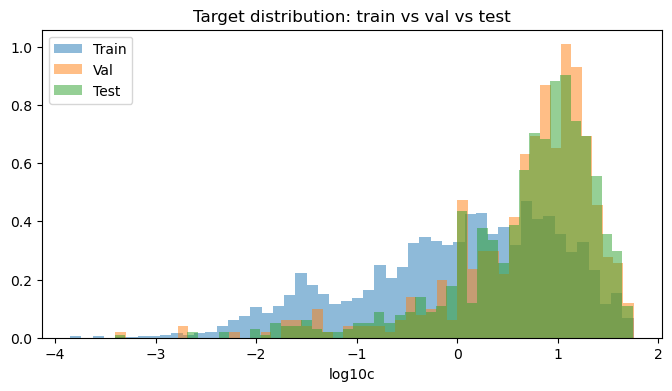

In [82]:
target_mean = train_targets_before.mean()
target_std = train_targets_before.std()

for dataset in (train_dataset, val_dataset, test_dataset):
    for g in dataset:
        g.y = (g.y - target_mean) / target_std

train_targets_after = np.array([g.y.item() for g in train_dataset])
val_targets_after = np.array([g.y.item() for g in val_dataset])
test_targets_after = np.array([g.y.item() for g in test_dataset])

print(f"Mean used: {target_mean:.4f}")
print(f"Std used:  {target_std:.4f}")
print()
print("Target distribution after normalization")
print(f"Train mean/std: {train_targets_after.mean():.4f} / {train_targets_after.std():.4f}")
print(f"Val mean/std:   {val_targets_after.mean():.4f} / {val_targets_after.std():.4f}")
print(f"Test mean/std:  {test_targets_after.mean():.4f} / {test_targets_after.std():.4f}")

plot_toxicity_distribution(train_dataset, test_dataset, val_dataset=val_dataset)


## Build DataLoaders


In [94]:
batch_size = 256
use_species_ratio_sampler = True
# Eval samplers use replacement, so validation/test metrics become stochastic when enabled.
apply_species_ratio_sampler_to_eval = True
species_sampler_attribute = "species_group"
sampler_replacement = True

species_target_distribution = compute_attribute_distribution(features, species_sampler_attribute)
train_species_distribution = compute_attribute_distribution(train_dataset, species_sampler_attribute)
val_species_distribution = compute_attribute_distribution(val_dataset, species_sampler_attribute)
test_species_distribution = compute_attribute_distribution(test_dataset, species_sampler_attribute)

train_sampler = None
val_sampler = None
test_sampler = None

if use_species_ratio_sampler:
    train_sampler = build_weighted_random_sampler(
        train_dataset,
        attribute_name=species_sampler_attribute,
        target_distribution=species_target_distribution,
        replacement=sampler_replacement,
    )

    if apply_species_ratio_sampler_to_eval:
        val_sampler = build_weighted_random_sampler(
            val_dataset,
            attribute_name=species_sampler_attribute,
            target_distribution=species_target_distribution,
            replacement=sampler_replacement,
        )
        test_sampler = build_weighted_random_sampler(
            test_dataset,
            attribute_name=species_sampler_attribute,
            target_distribution=species_target_distribution,
            replacement=sampler_replacement,
        )

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=train_sampler is None,
    sampler=train_sampler,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    sampler=val_sampler,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    sampler=test_sampler,
)

species_ratio_summary = (
    pd.DataFrame(
        {
            "target_ratio": pd.Series(species_target_distribution),
            "train_ratio": pd.Series(train_species_distribution),
            "val_ratio": pd.Series(val_species_distribution),
            "test_ratio": pd.Series(test_species_distribution),
        }
    )
    .fillna(0.0)
    .rename_axis(species_sampler_attribute)
    .reset_index()
)
species_ratio_summary["max_split_gap"] = (
    species_ratio_summary[["train_ratio", "val_ratio", "test_ratio"]]
    .sub(species_ratio_summary["target_ratio"], axis=0)
    .abs()
    .max(axis=1)
)

first_batch = next(iter(train_loader))

print(f"Batch size: {batch_size}")
print(f"Species sampler enabled: {use_species_ratio_sampler}")
print(f"Eval samplers enabled: {apply_species_ratio_sampler_to_eval}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print()
print(f"Largest {species_sampler_attribute} ratio gaps before sampling")
species_ratio_summary_display = species_ratio_summary.copy()
species_ratio_summary_display["species_group_label"] = (
    species_ratio_summary_display[species_sampler_attribute]
    .map(species_decoder)
    .fillna("Missing")
)

display(
    species_ratio_summary_display
    .sort_values(["max_split_gap", "target_ratio"], ascending=[False, False])
    .head(10)[
        [
            "species_group_label",
            "target_ratio",
            "train_ratio",
            "val_ratio",
            "test_ratio",
            "max_split_gap",
        ]
    ]
)
print()
print("First batch summary")
print(f"Graphs in batch: {first_batch.num_graphs}")
print(f"x shape: {tuple(first_batch.x.shape)}")
print(f"edge_index shape: {tuple(first_batch.edge_index.shape)}")
print(f"edge_attr shape: {tuple(first_batch.edge_attr.shape)}")
print(f"y shape: {tuple(first_batch.y.shape)}")


Batch size: 256
Species sampler enabled: True
Eval samplers enabled: True
Train batches per epoch: 14
Val batches: 2
Test batches: 4

Largest species_group ratio gaps before sampling


,species_group_label,target_ratio,train_ratio,val_ratio,test_ratio,max_split_gap
4,rodents,0.281575,0.148397,0.610998,0.582653,0.329423
3,fish,0.179147,0.214577,0.091650,0.098980,0.087497
7,insects,0.115079,0.146064,0.042770,0.042857,0.072309
1,plants,0.098347,0.120117,0.038697,0.052041,0.059651
2,crustaceans,0.121608,0.143149,0.077393,0.068367,0.053240
8,mollusks,0.024077,0.032653,0.002037,0.005102,0.022040
0,algae,0.064477,0.058309,0.071283,0.082653,0.018176
9,worms,0.026933,0.033528,0.010183,0.012245,0.016750
12,fungi,0.014487,0.017784,0.000000,0.010204,0.014487
6,amphibians,0.017547,0.022157,0.004073,0.008163,0.013474



First batch summary
Graphs in batch: 256
x shape: (3956, 7)
edge_index shape: (2, 8034)
edge_attr shape: (8034, 3)
y shape: (256,)


# Model and training


## Build model

In [95]:
from src.models.attentive_fp import AttentiveFP
from src.models.afp_flex import AFPFlex
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder, TaxonomyEncoder, TaxonomyOneHot

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TAX_DIM = 32
PRETRAINED_TAXID_OUTPUT_DIM = 32
CATEGORICAL_DIM = 16
NUMERIC_DIM = 16
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 64
GNN_OUT_DIM = 64

NUM_LAYERS = 3
NUM_TIMESTEPS = 2
DROPOUT = 0.4

FINAL_HIDDEN_DIM = 64

ATOM_FEATURE_DIM = features[0].x.shape[1]
EDGE_FEATURE_DIM = features[0].edge_attr.shape[1]

meta_encoder = MetaEncoder(
    taxonomy_encoder_cls=TaxonomyOneHot,
    config_tax=config_tax,
    tax_output_dim=TAX_DIM,
    pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
    pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
    config_categorical=config_categorical,
    categorical_output_dim=CATEGORICAL_DIM,
    numerical_columns=numerical_cols,
    numeric_output_dim=NUMERIC_DIM,
    dropout=META_DROPOUT
).to(device)


model_gnn = AFPFlex(
    in_channels=ATOM_FEATURE_DIM,
    edge_dim=EDGE_FEATURE_DIM,
    hidden_channels=GNN_HIDDEN_DIM,
    out_channels=GNN_OUT_DIM,
    num_layers=NUM_LAYERS,
    num_timesteps=NUM_TIMESTEPS,
    dropout=DROPOUT,
).to(device)

model = ToxicityModel(
    model_gnn,
    meta_encoder,
    hidden_dim=FINAL_HIDDEN_DIM,
).to(device)

n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad)
n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad)
n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"Device: {device}")
print(f"Meta encoder trainable parameters: {n_params_meta:,}")
print(f"GNN trainable parameters: {n_params_gnn:,}")
print(f"Total trainable parameters: {n_params_total:,}")
print()
print(model)


Device: cpu
Meta encoder trainable parameters: 617,920
GNN trainable parameters: 130,112
Total trainable parameters: 758,529

ToxicityModel(
  (gnn): AFPFlex(
    (lin1): Linear(in_features=7, out_features=64, bias=True)
    (gate_conv): GATEConv()
    (gru): GRUCell(64, 64)
    (atom_convs): ModuleList(
      (0-1): 2 x GATConv(64, 64, heads=1)
    )
    (atom_grus): ModuleList(
      (0-1): 2 x GRUCell(64, 64)
    )
    (mol_conv): GATConv(64, 64, heads=1)
    (mol_gru): GRUCell(64, 64)
    (linlone): Linear(in_features=64, out_features=64, bias=True)
    (lin2): Linear(in_features=64, out_features=64, bias=True)
  )
  (meta_encoder): MetaEncoder(
    (tax_encoder): TaxonomyOneHot(
      (projection): Sequential(
        (0): Linear(in_features=18, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.3, inplace=False)
      )
    )
    (categorical_encoder): CategoricalOneHot(
      (projection): Sequential(
        (0): Linear(in_features=32, out_features=16, bia

## Train The Model


wandb not installed; running without experiment tracking.
Training configuration
epochs = 100
learning_rate = 0.0003
weight_decay = 0.0001
loss = SmoothL1Loss
early_stopping_patience = 30


Epoch 100/100: 100%|██████████| 100/100 [01:32<00:00,  1.08epoch/s, train_loss=0.1919, val_loss=0.2860, val_rmse=0.6097, val_mae=0.4833, test_loss=0.2844, test_rmse=0.6221, test_mae=0.4788, lr=7.50e-05]


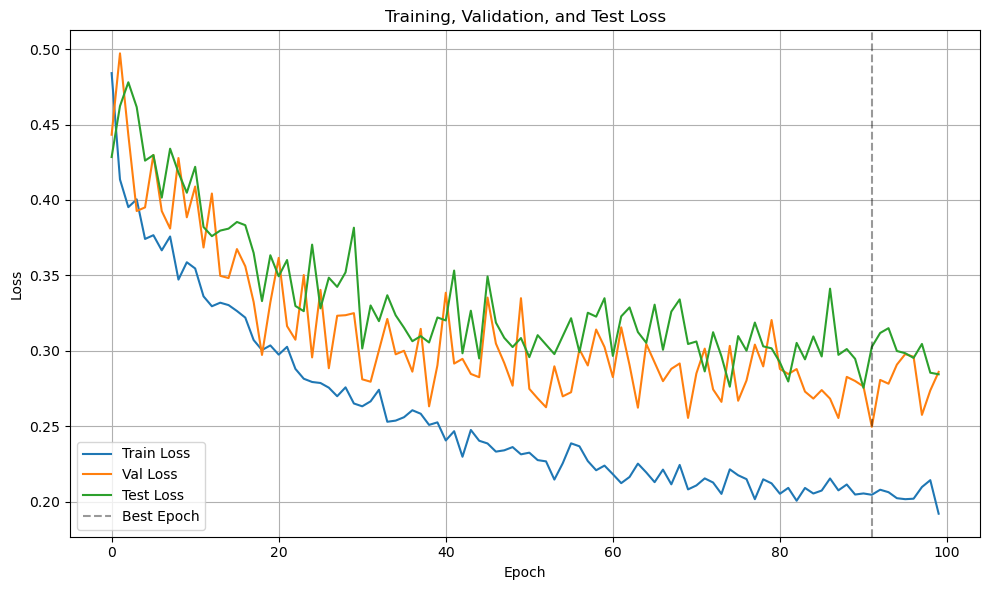

In [96]:
epochs = 100
learning_rate = 3e-4
weight_decay = 1e-4
loss_beta = 0.5
early_stopping_patience = 30
early_stopping_min_delta = 1e-4

loss_fn = torch.nn.SmoothL1Loss(beta=loss_beta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
    min_lr=1e-6,
)

USE_WANDB = wandb is not None  # set to False to skip tracking
USE_WANDB = False  # set to False to skip tracking
wandb_run = None

if USE_WANDB:
    wandb_run = wandb.init(
        project="gnn-thesis",
        entity="elonvg-chalmers-university-of-technology",
        job_type="train",
        tags=["notebook", split_method, type(model_gnn).__name__],
        config={
            "random_state": random_state,
            "n_samples": MAX_ROWS,

            "filters": filters,
            "split_salt": SPLIT_SALTS,
            "remove_lone": REMOVE_LONE,
            "remove_metals": REMOVE_METALS,
            "max_conc_value": MAX_CONC_VALUE,
            "duration_fill_value": DURATION_FILL_VALUE,
            "max_duration_hours": MAX_DURATION_HOURS,
            "log_transform_duration": LOG_TRANSFORM_DURATION,

            "num_atom_features": ATOM_FEATURE_DIM,
            "num_bond_features": EDGE_FEATURE_DIM,

            "tax_embedding": tax_embedding,
            "use_pretrained_taxid": USE_PRETRAINED_TAXID,
            "categorical_cols": categorical_cols,
            "numerical_cols": numerical_cols,

            "split_method": split_method,
            "butina_cluster_col": cluster_col,
            "frac_train": frac_train,
            "frac_valid": frac_valid,
            "frac_test": frac_test,
            "target_mean": float(target_mean),
            "target_std": float(target_std),

            "batch_size": batch_size,
            "taxonomy_encoder": TaxonomyOneHot.__name__,
            "gnn_model": type(model_gnn).__name__,
            "tax_dim": TAX_DIM,
            "pretrained_taxid_output_dim": PRETRAINED_TAXID_OUTPUT_DIM,
            "categorical_dim": CATEGORICAL_DIM,
            "numeric_dim": NUMERIC_DIM,
            "meta_dropout": META_DROPOUT,
            "gnn_hidden_dim": GNN_HIDDEN_DIM,
            "gnn_out_dim": GNN_OUT_DIM,
            "num_layers": NUM_LAYERS,
            "num_timesteps": NUM_TIMESTEPS,
            "dropout": DROPOUT,
            "final_hidden_dim": FINAL_HIDDEN_DIM,
            "n_params_meta": n_params_meta,
            "n_params_gnn": n_params_gnn,
            "n_params_total": n_params_total,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "loss": loss_fn.__class__.__name__,
            "loss_beta": loss_beta,
            "early_stopping_patience": early_stopping_patience,
            "early_stopping_min_delta": early_stopping_min_delta,
        },
    )
    wandb_run.define_metric("epoch")
    for metric_prefix in ("train/*", "val/*", "test/*", "optimizer/*"):
        wandb_run.define_metric(metric_prefix, step_metric="epoch")
else:
    print("wandb not installed; running without experiment tracking.")

print("Training configuration")
print(f"epochs = {epochs}")
print(f"learning_rate = {learning_rate}")
print(f"weight_decay = {weight_decay}")
print(f"loss = {loss_fn.__class__.__name__}")
print(f"early_stopping_patience = {early_stopping_patience}")

model_trained, history = train(
    model,
    train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=epochs,
    device=device,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    run=wandb_run,
)

model = model_trained
plot_training(history)


# Results

## Check Overall Test Performance

In [97]:
from src.training.loops import predict_df
from src.visualization.result_plots import summarize_by_group, plot_group_mae

analysis_df = df_processed.reset_index(drop=True)[[
    "species_group",
    "species_sci_name",
    "endpoint",
    "effect",
    "fragment_count",
    "has_metal",
    "is_single_node",
    "conc_unit"
]].copy()
analysis_df = analysis_df.rename(columns={"species_sci_name": "species_latin_name"})
analysis_df["fragment_bin"] = pd.cut(analysis_df["fragment_count"], [-1, 1, 2, np.inf], labels=["1", "2", "3+"])
analysis_df["has_metal_group"] = analysis_df["has_metal"].map({0.0: "No metal", 1.0: "Has metal"})
analysis_df["is_single_group"] = analysis_df["is_single_node"].map({0.0: "Not single-node", 1.0: "Single-node"})

results_df = predict_df(model, test_loader, device, cols=["row_id", "smiles", "taxid_raw"])
results_df["row_id"] = results_df["row_id"].astype(int)
results_df["taxid"] = results_df["taxid_raw"].astype(int)
results_df = results_df.drop(columns="taxid_raw").join(analysis_df, on="row_id")

results_df["pred_log10c"] = results_df["pred_norm"] * target_std + target_mean
results_df["actual_log10c"] = results_df["actual_norm"] * target_std + target_mean
results_df["residual_log10c"] = results_df["pred_log10c"] - results_df["actual_log10c"]
results_df["abs_error_log10c"] = results_df["residual_log10c"].abs()
results_df["pred_conc"] = 10 ** results_df["pred_log10c"]
results_df["actual_conc"] = 10 ** results_df["actual_log10c"]
results_df["fold_error"] = np.maximum(
    results_df["pred_conc"] / results_df["actual_conc"],
    results_df["actual_conc"] / results_df["pred_conc"],
)

train_df = analysis_df.iloc[[g.row_id.item() for g in train_dataset]].copy()

summary_metrics = {
    "test/r2_norm": r2_score(results_df["actual_norm"], results_df["pred_norm"]),
    "test/r2_log10c": r2_score(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/rmse_log10c": mean_squared_error(results_df["actual_log10c"], results_df["pred_log10c"]) ** 0.5,
    "test/mae_log10c": mean_absolute_error(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/median_fold_error": results_df["fold_error"].median(),
}

print("Overall test-set metrics")
print(f"R^2 (normalized target): {summary_metrics['test/r2_norm']:.3f}")
print(f"R^2 (log10c): {summary_metrics['test/r2_log10c']:.3f}")
print(f"RMSE (log10c): {summary_metrics['test/rmse_log10c']:.3f}")
print(f"MAE (log10c): {summary_metrics['test/mae_log10c']:.3f}")
print(f"Median fold error (conc scale): {summary_metrics['test/median_fold_error']:.3f}")

if wandb_run is not None:
    wandb_run.summary.update(summary_metrics)

    predictions_for_wandb = results_df[[
        "row_id",
        "smiles",
        "taxid",
        "species_latin_name",
        "species_group",
        "endpoint",
        "effect",
        "fragment_bin",
        "has_metal_group",
        "is_single_group",
        "actual_norm",
        "pred_norm",
        "actual_log10c",
        "pred_log10c",
        "residual_log10c",
        "abs_error_log10c",
        "fold_error",
    ]].copy()
    predictions_for_wandb["fragment_bin"] = predictions_for_wandb["fragment_bin"].astype(str)
    wandb_run.log({"predictions/test": wandb.Table(dataframe=predictions_for_wandb)})

largest_errors = results_df[[
    "species_latin_name",
    "species_group",
    "endpoint",
    "effect",
    "actual_log10c",
    "pred_log10c",
    "abs_error_log10c",
    "fold_error",
    "smiles",
]].sort_values("abs_error_log10c", ascending=False).head(10)

largest_errors


Overall test-set metrics
R^2 (normalized target): 0.450
R^2 (log10c): 0.450
RMSE (log10c): 1.570
MAE (log10c): 1.179
Median fold error (conc scale): 7.598


,species_latin_name,species_group,endpoint,effect,actual_log10c,pred_log10c,abs_error_log10c,fold_error,smiles
676,bipolaris sorokiniana,fungi,NOEC,POP,-6.481615,0.134434,6.616049,4.130938e+06,COC(=O)c1c(Cl)c(Cl)c(C(=O)OC)c(Cl)c1Cl
753,valsa mali,fungi,EC50,POP,-4.038105,2.129471,6.167575,1.470873e+06,C[Si](Cn1cncn1)(c1ccc(F)cc1)c1ccc(F)cc1
580,valsa mali,fungi,EC50,POP,-4.038105,2.129471,6.167575,1.470873e+06,C[Si](Cn1cncn1)(c1ccc(F)cc1)c1ccc(F)cc1
275,drosophila melanogaster,insects,EC50,REP,-2.886057,2.469537,5.355594,2.267745e+05,BrCC1CO1
498,drosophila melanogaster,insects,EC50,REP,-2.886057,2.469537,5.355594,2.267745e+05,BrCC1CO1
777,drosophila melanogaster,insects,EC50,REP,-2.886057,2.469537,5.355594,2.267745e+05,BrCC1CO1
334,lemna minor,plants,EC50,DVP,3.979953,-1.363896,5.343849,2.207238e+05,CC1CCC(O)C=CC(=O)OC(C)CCC(O)C=CC(=O)O1
293,lemna gibba,plants,EC50,POP,2.380211,-2.635575,5.015787,1.037019e+05,O=C1c2cccc(Sc3ccccc3)c2C(=O)c2c(Sc3ccccc3)cccc21
773,lemna gibba,plants,EC50,POP,2.380211,-2.635575,5.015787,1.037019e+05,O=C1c2cccc(Sc3ccccc3)c2C(=O)c2c(Sc3ccccc3)cccc21
796,lemna gibba,plants,EC50,POP,2.380211,-2.635575,5.015787,1.037019e+05,O=C1c2cccc(Sc3ccccc3)c2C(=O)c2c(Sc3ccccc3)cccc21


## Visual Result Checks

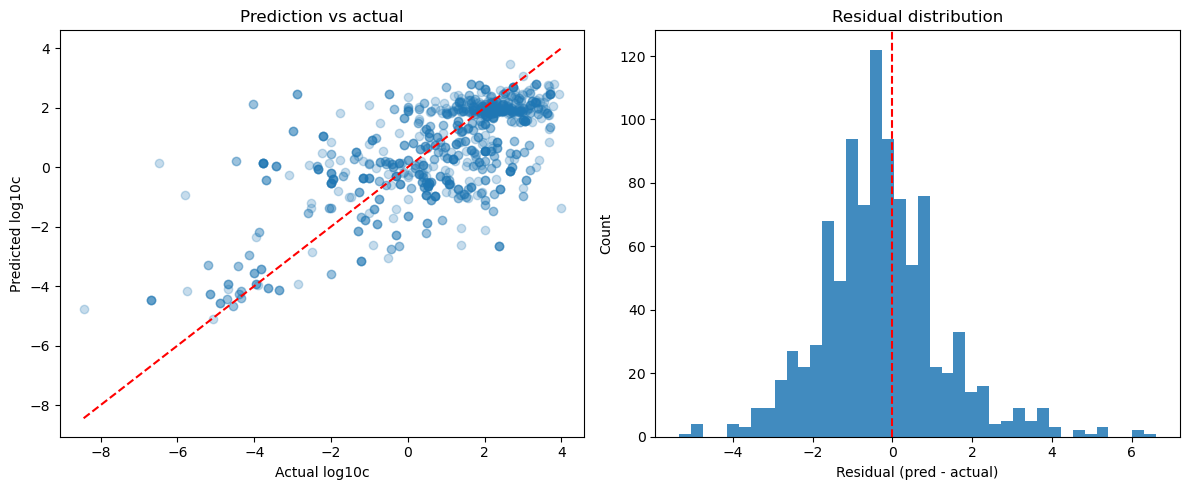

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["actual_log10c"], results_df["pred_log10c"], alpha=0.25)
plot_min = min(results_df["actual_log10c"].min(), results_df["pred_log10c"].min())
plot_max = max(results_df["actual_log10c"].max(), results_df["pred_log10c"].max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set_xlabel("Actual log10c")
axes[0].set_ylabel("Predicted log10c")
axes[0].set_title("Prediction vs actual")

axes[1].hist(results_df["residual_log10c"], bins=40, alpha=0.85)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


## Performance By Group

Conc Unit


,group,n,model_mae,baseline_mae,mae_gain
0,mg/L,496,1.453741,1.566999,0.113258
1,mg/kg,276,0.744260,0.667985,-0.076276
2,ppm,82,1.266720,1.817102,0.550382
3,kg/m2,54,1.098657,0.942881,-0.155776


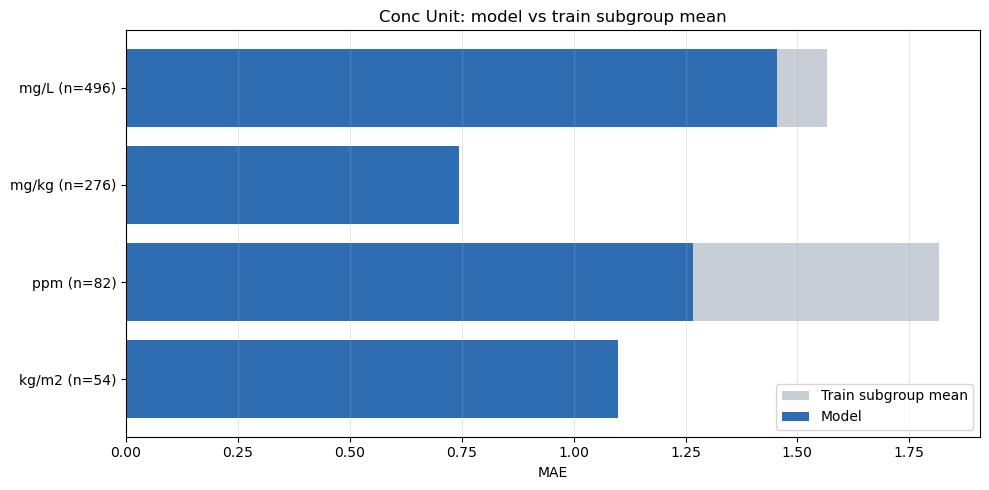

Species Group


,group,n,model_mae,baseline_mae,mae_gain
0,rodents,272,0.699812,0.744376,0.044564
1,fish,166,1.136627,1.598380,0.461753
2,crustaceans,140,1.323893,1.453518,0.129625
3,insects,109,1.863162,2.568537,0.705375
4,plants,95,1.507524,2.839654,1.332130
5,algae,54,1.096132,1.283082,0.186951
6,birds,30,0.823036,1.124400,0.301364
7,worms,25,1.036208,1.408990,0.372783


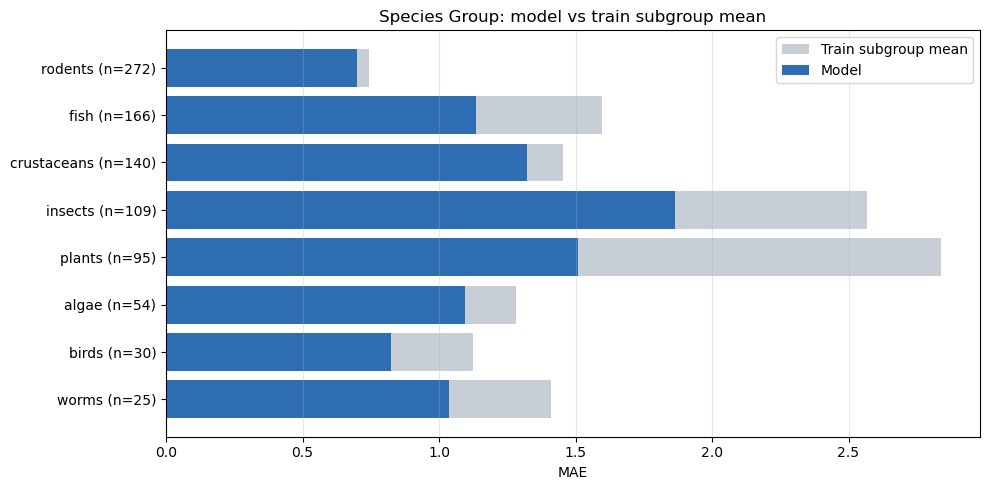

Endpoint


,group,n,model_mae,baseline_mae,mae_gain
0,EC50,601,1.072920,1.745762,0.672841
1,NOEC,255,1.362417,2.195410,0.832993
2,LOEC,93,1.370571,2.209704,0.839133
3,EC10,31,1.160730,1.184534,0.023804


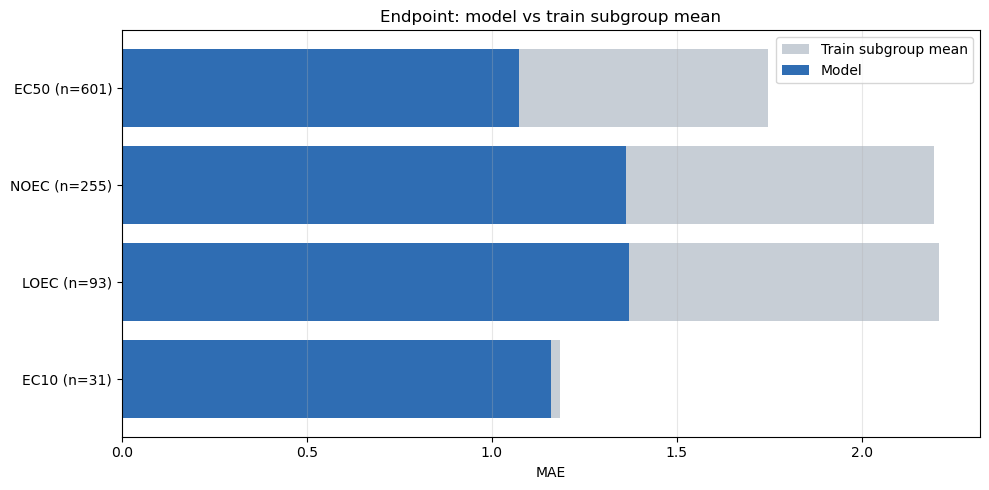

Effect


,group,n,model_mae,baseline_mae,mae_gain
0,MOR,533,1.035119,1.801528,0.766408
1,POP,99,1.379330,2.697841,1.318511
2,GRO,91,1.404369,2.092035,0.687666
3,ITX,71,1.416975,1.437910,0.020935
4,REP,58,1.241410,1.639545,0.398135
5,BEH,57,0.956575,1.653982,0.697407
6,DVP,41,1.888934,2.466947,0.578013
7,PHY,25,1.219674,1.693861,0.474187


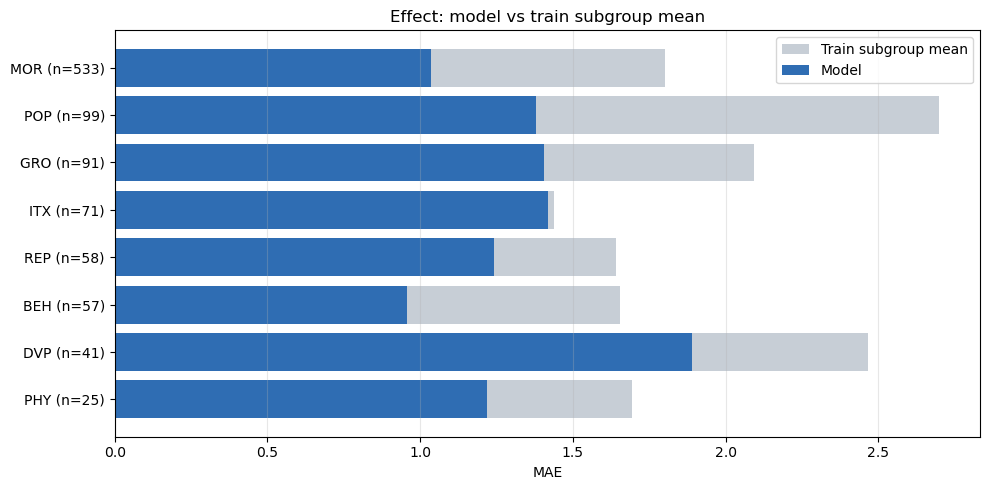

Fragment Bin


,group,n,model_mae,baseline_mae,mae_gain
0,1,980,1.179273,2.04557,0.866297


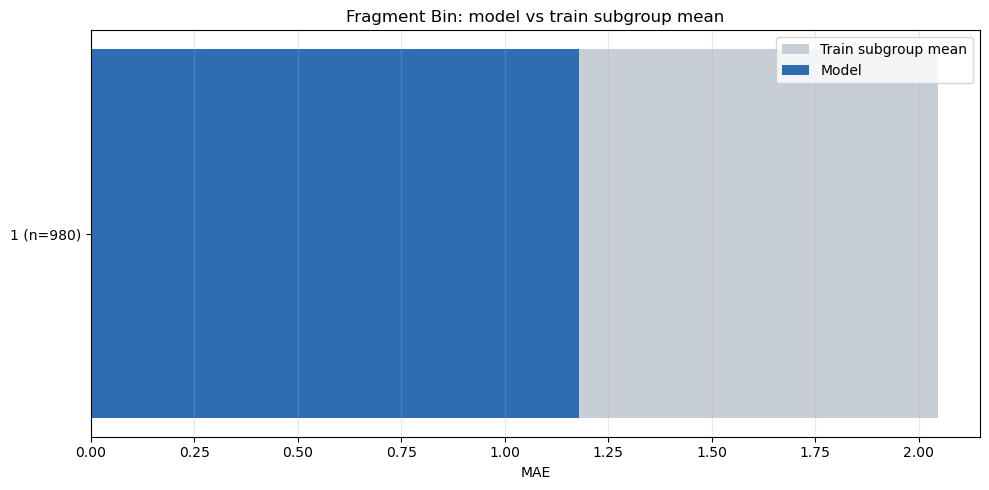

Has Metal Group


,group,n,model_mae,baseline_mae,mae_gain
0,No metal,947,1.177323,2.101788,0.924465
1,Has metal,33,1.235231,1.287291,0.052060


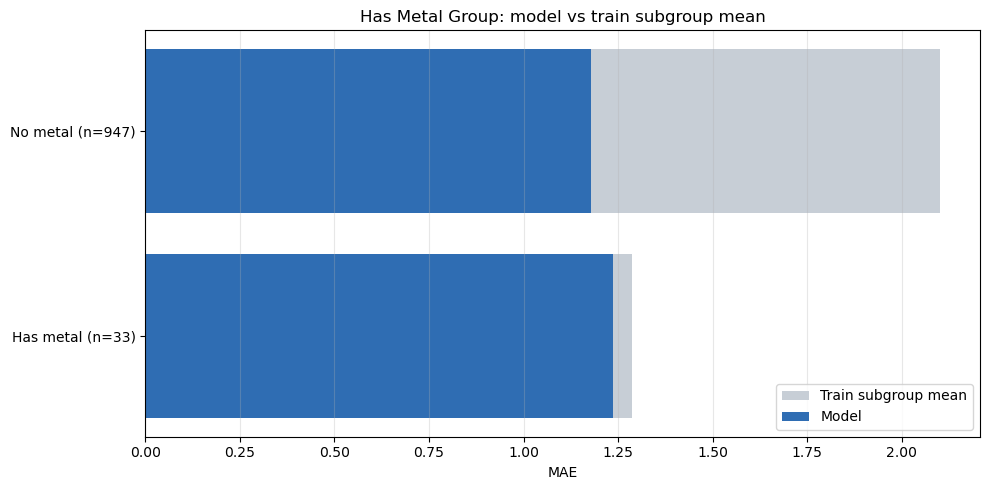

Top species with at least 20 test rows


,group,n,model_mae,baseline_mae,mae_gain
0,mus musculus,206,0.670708,0.642510,-0.028198
1,daphnia magna,101,1.300305,1.342075,0.041770
2,rattus norvegicus,66,0.790653,0.970142,0.179489
3,pimephales promelas,40,0.846978,1.618912,0.771934
4,oncorhynchus mykiss,32,1.179944,1.471489,0.291546
5,danio rerio,28,1.611790,1.587591,-0.024198
6,raphidocelis subcapitata,25,1.080549,1.268781,0.188233


Single-node support on the test set
is_single_group
Not single-node    966
Single-node         14


In [99]:
group_cols = [
    "conc_unit",
    "species_group",
    "endpoint",
    "effect",
    "fragment_bin",
    "has_metal_group",
]

train_df["actual_log10c"] = [g.y.item() * target_std + target_mean for g in train_dataset]

group_summaries = {}
for group_col in group_cols:
    title = group_col.replace("_", " ").title()
    summary = summarize_by_group(results_df, train_df, group_col, min_count=25)
    group_summaries[group_col] = summary

    print(title)
    display(summary[["group", "n", "model_mae", "baseline_mae", "mae_gain"]])
    plot_group_mae(summary, title=f"{title}: model vs train subgroup mean")

species_summary = summarize_by_group(results_df, train_df, "species_latin_name", min_count=20)
print("Top species with at least 20 test rows")
display(species_summary.head(15)[["group", "n", "model_mae", "baseline_mae", "mae_gain"]])

print("Single-node support on the test set")
print(results_df["is_single_group"].value_counts(dropna=False).to_string())

if wandb_run is not None:
    for group_col, summary in group_summaries.items():
        wandb_run.log({f"group_summary/{group_col}": wandb.Table(dataframe=summary)})
    wandb_run.log({"group_summary/species_latin_name": wandb.Table(dataframe=species_summary)})
    wandb_run.finish()
